# Telco Customer Churn — End-to-End Analysis Notebook

This notebook walks through the full ML lifecycle for this project: data understanding,
EDA, preprocessing, model training/tuning, and evaluation. It calls into the reusable
modules in `src/` rather than duplicating logic, so the notebook and the production
scripts (`src/train.py`, `src/evaluate.py`, `app/app.py`) always stay in sync.

**Run this notebook with the project's virtual environment active, from the project root
(or adjust the `sys.path` cell below if running from within `notebooks/`).**


In [1]:
import sys
from pathlib import Path

# Make src/ importable when running this notebook from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Load & Inspect Raw Data

In [2]:
from preprocessing import load_and_clean, DATA_PATH

raw_df = pd.read_csv(DATA_PATH)
print("Raw shape:", raw_df.shape)
raw_df.head()


Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Observation:** `TotalCharges` is loaded as an `object` (string) column, not numeric —
this is the first data-quality issue we need to handle (see Section 2).

## 2. Data Cleaning (via `src/preprocessing.py`)

In [4]:
df = load_and_clean()
print("Cleaned shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
df.head()


Cleaned shape: (7021, 20)
Missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**What `load_and_clean()` does, and why:**
- Drops `customerID` — a unique identifier with no predictive signal.
- Coerces `TotalCharges` to numeric; the resulting NaNs (11 rows) all correspond to
  `tenure == 0` (brand-new customers not yet billed) so we impute them as `0`, which is
  the structurally correct value rather than a guess.
- Drops 22 exact duplicate rows.
- Casts `SeniorCitizen` (originally 0/1 int) to string so it's treated as categorical.
- Encodes the target `Churn` as 0/1.


## 3. Exploratory Data Analysis

Overall churn rate: 26.4%


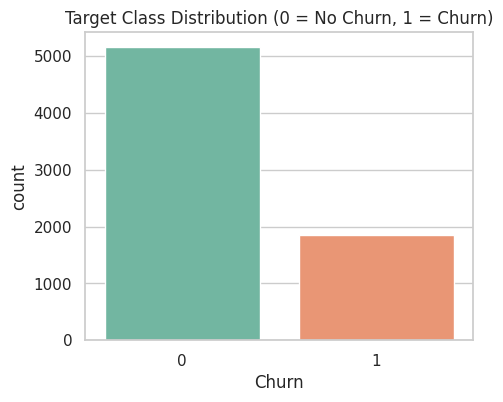

In [5]:
churn_rate = df["Churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Target Class Distribution (0 = No Churn, 1 = Churn)")
plt.show()


**Observation:** the classes are imbalanced (~73% retained / ~27% churned). This is
why we use ROC-AUC (not raw accuracy) as our primary model-selection metric later, and
why we apply class weighting during training.

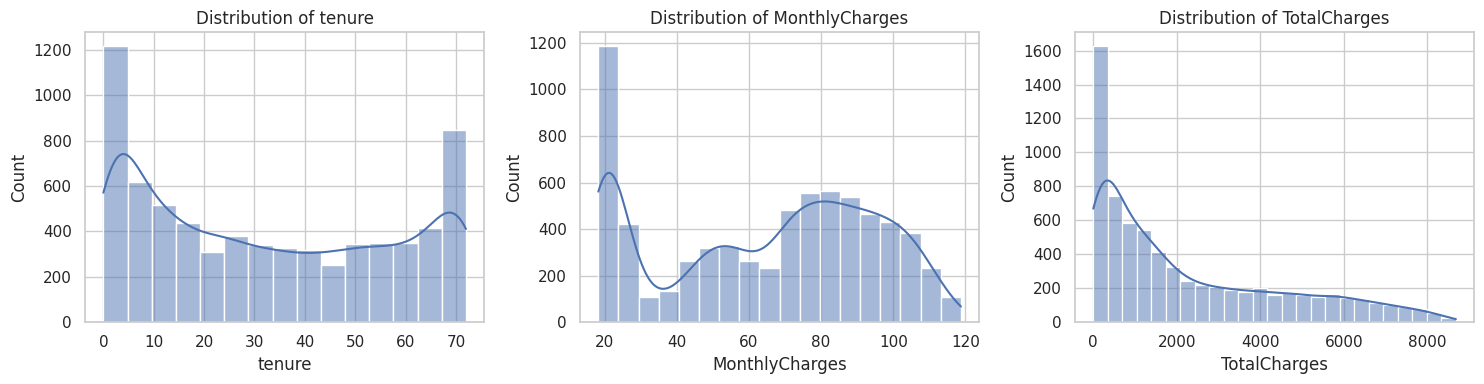

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


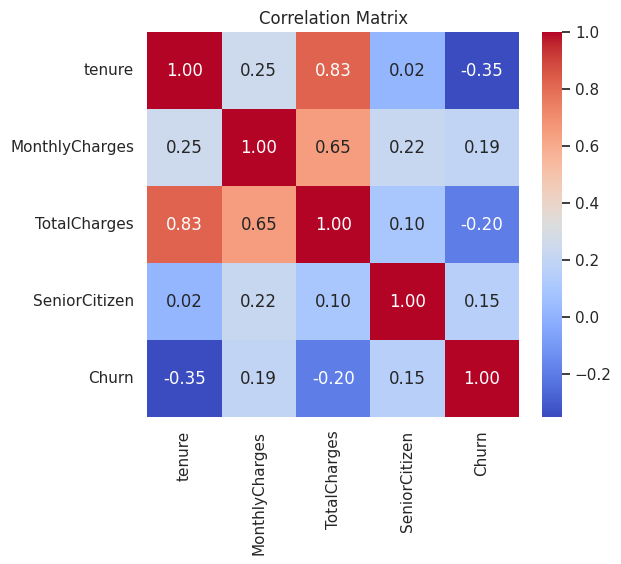

In [7]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
corr_df = df.copy()
corr_df["SeniorCitizen"] = corr_df["SeniorCitizen"].astype(int)
plt.figure(figsize=(6,5))
sns.heatmap(corr_df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [8]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    rate = df.groupby(col)["Churn"].mean().sort_values() * 100
    print(f"\nChurn rate by {col}:")
    print(rate.round(1))



Churn rate by Contract:
Contract
Two year           2.8
One year          11.3
Month-to-month    42.6
Name: Churn, dtype: float64

Churn rate by InternetService:
InternetService
No              7.2
DSL            18.9
Fiber optic    41.8
Name: Churn, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod
Credit card (automatic)      15.2
Bank transfer (automatic)    16.7
Mailed check                 18.9
Electronic check             45.1
Name: Churn, dtype: float64


**Key insight:** month-to-month contracts, fiber-optic internet, and electronic-check
payment are all associated with meaningfully higher churn rates — these show up later as
top features in the trained model's feature-importance ranking.

Full EDA detail (plots + written notes) is also saved to `reports/eda_summary.md` and
`reports/images/` by running `python src/eda.py` directly.

## 4. Train/Test Split & Preprocessing Pipeline

In [9]:
from preprocessing import get_train_test_split, build_preprocessor

X_train, X_test, y_train, y_test = get_train_test_split()
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))


Train: (5616, 19)  Test: (1405, 19)
Train churn rate: 0.264  Test churn rate: 0.265


The split is **stratified** on the target so both train and test sets preserve the
~73/27 class ratio. `build_preprocessor()` returns a `ColumnTransformer` (StandardScaler
for numeric features, OneHotEncoder for categoricals) that gets bundled into the same
`Pipeline` as the model — so there is exactly one place the encoding/scaling logic lives,
reused identically at training and inference time.

## 5. Baseline Model

In [10]:
from train import run_baseline

baseline_metrics = run_baseline(X_train, y_train, X_test, y_test)
baseline_metrics


{'accuracy': 0.802846975088968,
 'precision': 0.6610169491525424,
 'recall': 0.5241935483870968,
 'f1': 0.5847076461769115,
 'roc_auc': 0.8403139930674827}

**Baseline = untuned Logistic Regression.** This sets the floor — any tuned model that
doesn't beat this on the metric we actually care about (ROC-AUC, given class imbalance)
wouldn't justify its added complexity.

## 6. Model Training & Hyperparameter Tuning (3 candidates)

In [11]:
from train import tune_logistic_regression, tune_random_forest, tune_xgboost, evaluate
import time

results = {}
fitted = {}

t0 = time.time()
lr_search = tune_logistic_regression(X_train, y_train)
fitted["logistic_regression"] = lr_search.best_estimator_
results["logistic_regression"] = evaluate(lr_search.best_estimator_, X_test, y_test)
print(f"Logistic Regression tuned in {time.time()-t0:.1f}s — best params: {lr_search.best_params_}")


Logistic Regression tuned in 1.6s — best params: {'model__C': 10, 'model__solver': 'lbfgs'}


In [12]:
t0 = time.time()
rf_search = tune_random_forest(X_train, y_train)
fitted["random_forest"] = rf_search.best_estimator_
results["random_forest"] = evaluate(rf_search.best_estimator_, X_test, y_test)
print(f"Random Forest tuned in {time.time()-t0:.1f}s — best params: {rf_search.best_params_}")


Random Forest tuned in 81.7s — best params: {'model__max_depth': 6, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}


In [13]:
t0 = time.time()
xgb_search = tune_xgboost(X_train, y_train)
fitted["xgboost"] = xgb_search.best_estimator_
results["xgboost"] = evaluate(xgb_search.best_estimator_, X_test, y_test)
print(f"XGBoost tuned in {time.time()-t0:.1f}s — best params: {xgb_search.best_params_}")


XGBoost tuned in 10.3s — best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}


All three use `GridSearchCV` with 5-fold **stratified** cross-validation, scored on
ROC-AUC. Class imbalance is addressed via `class_weight='balanced'` (Logistic Regression,
Random Forest) or `scale_pos_weight` (XGBoost) rather than resampling, to avoid distorting
the real-world class distribution the model will see in production.

## 7. Model Comparison & Evaluation

In [14]:
comparison = pd.DataFrame({"baseline_logreg": baseline_metrics, **results}).T
comparison[["accuracy","precision","recall","f1","roc_auc"]].round(3)


,accuracy,precision,recall,f1,roc_auc
baseline_logreg,0.803,0.661,0.524,0.585,0.840
logistic_regression,0.739,0.504,0.782,0.613,0.840
random_forest,0.742,0.509,0.790,0.619,0.841
xgboost,0.758,0.529,0.796,0.635,0.843


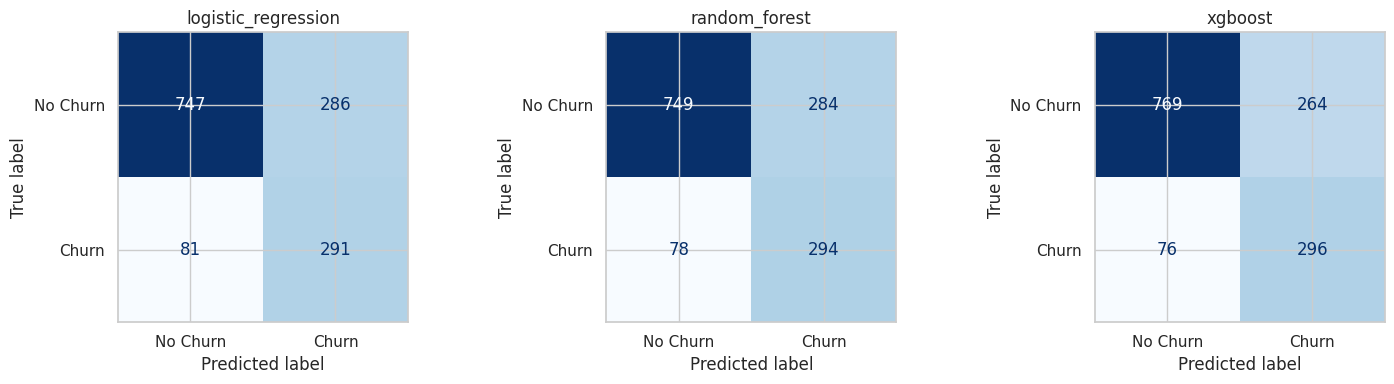

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["No Churn","Churn"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


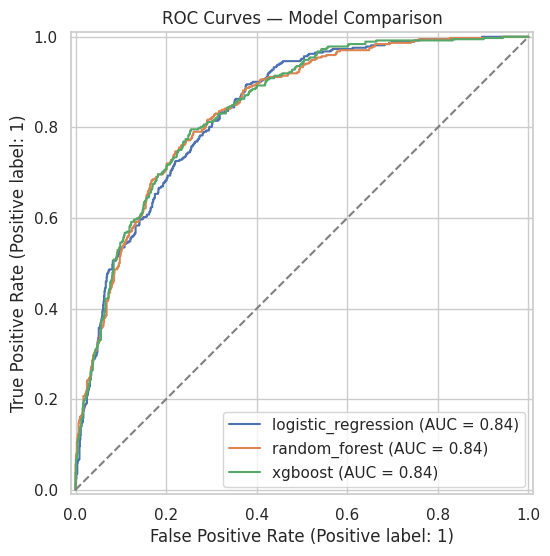

In [16]:
fig, ax = plt.subplots(figsize=(6,6))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1], linestyle="--", color="gray")
ax.set_title("ROC Curves — Model Comparison")
plt.show()


## 8. Final Model Selection

In [17]:
best_name = max(results, key=lambda k: results[k]["roc_auc"])
print("Best model (by test ROC-AUC):", best_name)
print(results[best_name])


Best model (by test ROC-AUC): xgboost
{'accuracy': 0.7580071174377224, 'precision': 0.5285714285714286, 'recall': 0.7956989247311828, 'f1': 0.6351931330472103, 'roc_auc': 0.8432129511080578}


**Selection rationale:** ROC-AUC (not accuracy) is the primary metric because the
target is imbalanced (~73/27) — a model that always predicts "No Churn" would already
score ~73% accuracy while being useless. ROC-AUC measures ranking quality across *all*
thresholds, which matters because a business would tune its decision threshold based on
the real cost of a retention offer vs. the cost of losing a customer, not just accept a
default 0.5 cutoff. Recall on the churn class is weighted heavily too — in this business
context, missing an actual churner (false negative) is typically costlier than an
unnecessary retention offer to a loyal customer (false positive).

The final selected pipeline (preprocessing + model bundled as one `sklearn.Pipeline`) is
saved by `src/train.py` to `models/saved_model/churn_model.joblib`, and reused by both
`src/predict.py` and the Streamlit app (`app/app.py`) — no logic is duplicated or
reimplemented outside this one saved pipeline.

## 9. Feature Importance

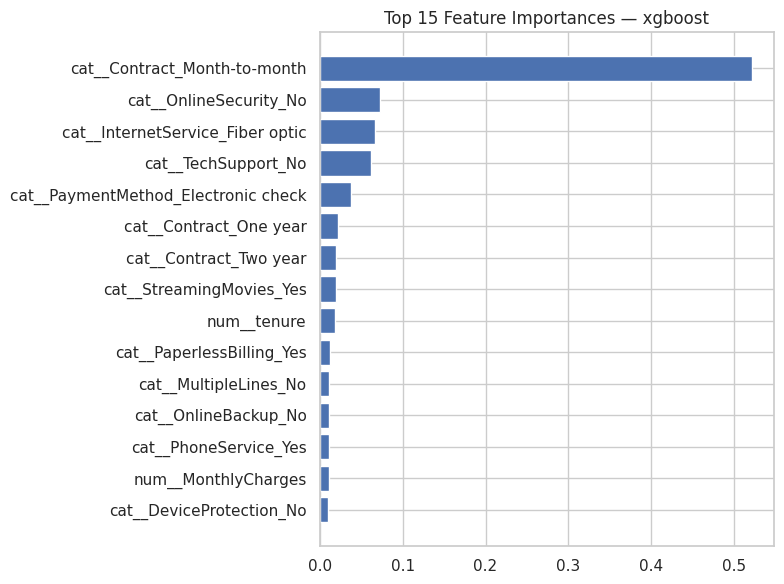

In [18]:
best_pipe = fitted[best_name]
preprocessor = best_pipe.named_steps["preprocessor"]
model = best_pipe.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

importances = model.feature_importances_ if hasattr(model, "feature_importances_") else np.abs(model.coef_[0])
order = np.argsort(importances)[-15:]

plt.figure(figsize=(8,6))
plt.barh(range(len(order)), importances[order])
plt.yticks(range(len(order)), [feature_names[i] for i in order])
plt.title(f"Top 15 Feature Importances — {best_name}")
plt.tight_layout()
plt.show()


## 10. Sanity-Check Prediction

Using the exact same reusable pipeline the Streamlit app calls (`src/predict.py`),
confirming the saved model loads and produces a sensible result on a synthetic
high-risk customer (new, month-to-month, fiber optic, electronic check).

In [19]:
from predict import predict_churn

sample_customer = {
    "tenure": 2, "MonthlyCharges": 95.0, "TotalCharges": 190.0,
    "gender": "Female", "SeniorCitizen": "0", "Partner": "No", "Dependents": "No",
    "PhoneService": "Yes", "MultipleLines": "No", "InternetService": "Fiber optic",
    "OnlineSecurity": "No", "OnlineBackup": "No", "DeviceProtection": "No",
    "TechSupport": "No", "StreamingTV": "Yes", "StreamingMovies": "Yes",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
}
predict_churn(sample_customer)


{'churn_prediction': 'Yes', 'churn_probability': 0.9047}

## Summary

- Cleaned and explored 7,043 telco customer records.
- Built a single reusable preprocessing pipeline (scaling + one-hot encoding).
- Trained and tuned 3 models plus a baseline, selected XGBoost on ROC-AUC (~0.84).
- Identified contract type, tenure, internet service, and payment method as the strongest
  churn drivers.
- Saved the winning pipeline and wired it into a Streamlit prediction app.

See `README.md` for full setup/run instructions, and `reports/` for the standalone
written summaries and all saved plots.